# **CS 412 HW1 - k-NN and Decision Tree on The Breast Cancer Wisconsin Dataset**
---
## **Name:** Abdallah Al Homsi
## **ID:** 34565
## **Semester:** Spring 2026

# 1. Notebook

## 1.1 Dataset and Preprocessing
---
In this section we load the Breast Cancer Wisconsin dataset and prepare it for machine learning.  
We analyze the dataset, visualize feature distributions, and preprocess the data.

### 1.1.1 Data Loading
---

The Breast Cancer Wisconsin dataset contains 569 samples
Each sample consists of 30 numerical features describing properties such as **radius, texture, and perimeter of cell nuclei.** (The first three features of the samples)

The task is a classification problem where the target label indicates whether the tumor is:

- malignant (cancerous)
- benign (non-cancerous)

The dataset is loaded using the `load_breast_cancer()` function from scikit-learn. (As mentioned in the PDF of the HW Assignment)

In [ ]:
# Import Libraries and Dataset, and Loading of Dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X,y = data.data, data.target

# Print to Ensure Loading of Data is Successful

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Feature names:", data.feature_names)
print("Target names:", data.target_names)




Dataset shape: (569, 30)
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']


In [ ]:
# Train/Validation/Test Split as Explained in the PDF and in Class 70% for training, 15% for validation, 15% for test
# Store into Temp variable in order to assign into validation and test meaning 0.3 for test_size in the first block is 70% went for training
# Then the 50% of the remaning 30% making it 15% into each of the validation and test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

# Printing of Training, Validation, and Test shapes

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (398, 30)
Validation set: (85, 30)
Test set: (86, 30)


### 1.1.2 Data Analysis
---
Before training machine learning models, it is important to understand the structure of the dataset.

In this section we examine:
- the distribution of classes (malignant vs benign) To check if its balanced or skewed
- Mean and and Standard Deviation for the first three features in the dataset
- the distribution of mean radius using a histogram visualization and coloring each class differently

In [ ]:
# Count number of malignant and benign samples

malignant_count = np.sum(y == 0)
benign_count = np.sum(y == 1)

print("Class distribution:")
print("Malignant (0):", malignant_count)
print("Benign (1):", benign_count)

total = len(y)
print("\nTotal samples:", total)
print("Malignant percentage:", malignant_count/total)
print("Benign percentage:", benign_count/total)

Class distribution:
Malignant (0): 212
Benign (1): 357

Total samples: 569
Malignant percentage: 0.37258347978910367
Benign percentage: 0.6274165202108963


### Is it Balanced or Skewed?

The dataset is slightly imbalanced. Approximately 63% of the samples are benign and 37% are malignant.  
Benign tumors appear more frequently in the dataset.
Making it Slighty Skewed

In [ ]:
# Printing the Mean and the Std of the first 3 features of the dataset

for i in range(3):

    mean_value = np.mean(X[:, i])
    std_value = np.std(X[:, i])

    print(data.feature_names[i])
    print("Mean:", mean_value)
    print("Standard deviation:", std_value)
    print()

mean radius
Mean: 14.127291739894552
Standard deviation: 3.520950760711062

mean texture
Mean: 19.289648506151142
Standard deviation: 4.297254637090421

mean perimeter
Mean: 91.96903339191564
Standard deviation: 24.27761929305318



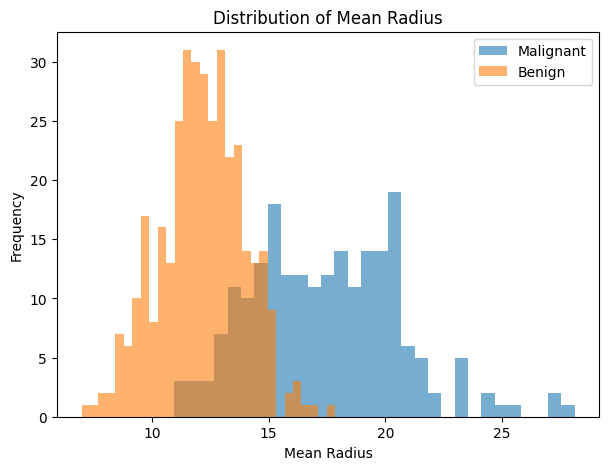

In [ ]:
# Histogram Visualization of mean radius

mean_radius = X[:,0]

plt.figure(figsize=(7,5))

plt.hist(mean_radius[y==0], bins=30, alpha=0.6, label="Malignant")
plt.hist(mean_radius[y==1], bins=30, alpha=0.6, label="Benign")

plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Radius")

plt.legend()

plt.show()

### 1.1.3 Data Preprocessing
---

Machine learning algorithms such as k-Nearest Neighbors rely on distance calculations between samples. (Euclidean Distance for instance)
So if features are not standarized some may dominate others to do that we set the mean as 0 and the standard deviation as 1



In [ ]:
mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)

X_train_std = (X_train - mean_train) / std_train
X_val_std = (X_val - mean_train) / std_train
X_test_std = (X_test - mean_train) / std_train

## 1.2 k-NN Classifier
---

In this section we implement the k-Nearest Neighbors (k-NN) algorithm for tumor classification.  


The algorithm relies on distance calculations between samples, which is why feature standardization was necessary in the preprocessing step.

### 1.2.1 Model Initialization and Hyperparameter Tuning
---

The k-NN classifier has a key hyperparameter: the number of neighbors (k).  
Small values of k may lead to overfitting, while large values may oversmooth the decision boundary.

To select the best value of k, we train the model using the training set and evaluate performance on the validation set.  
We test the following values:

k ∈ {1, 3, 5, 7, 9, 15, 21}

In [ ]:
# Import the classifer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#Checking Every K Value

k_values = [1,3,5,7,9,15,21]

validation_accuracies = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_std, y_train)

    y_val_pred = model.predict(X_val_std)

    acc = accuracy_score(y_val, y_val_pred)

    validation_accuracies.append(acc)

    print("k =", k, "Validation Accuracy =", acc)

k = 1 Validation Accuracy = 0.9176470588235294
k = 3 Validation Accuracy = 0.9294117647058824
k = 5 Validation Accuracy = 0.9294117647058824
k = 7 Validation Accuracy = 0.9294117647058824
k = 9 Validation Accuracy = 0.9529411764705882
k = 15 Validation Accuracy = 0.9529411764705882
k = 21 Validation Accuracy = 0.9529411764705882


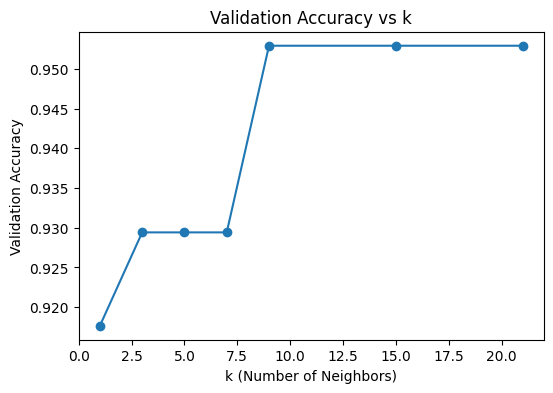

In [ ]:
# Plot Vailidation Accuracy vs K

plt.figure(figsize=(6,4))

plt.plot(k_values, validation_accuracies, marker='o')

plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs k")

plt.show()

As we Can see the highest validation accuracy was obtained when K = 9, 15, 21
So we choose the smallest k (9) as the optimal neighbors

In [ ]:
# Select Best K

best_k = k_values[np.argmax(validation_accuracies)]

print("Best k:", best_k)

Best k: 9


### 1.2.2 Final Model and Evaluation
---

After selecting the optimal value of k using the validation set, we retrain the k-NN model using both the training and validation sets combined.

The final model is then evaluated on the test set to estimate its performance on unseen data. (Generalization as explained in lectures)

In [ ]:
X_train_val = np.vstack((X_train_std, X_val_std))
y_train_val = np.concatenate((y_train, y_val))

In [ ]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_val, y_train_val)

y_test_pred = final_knn.predict(X_test_std)

In [ ]:
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9883720930232558


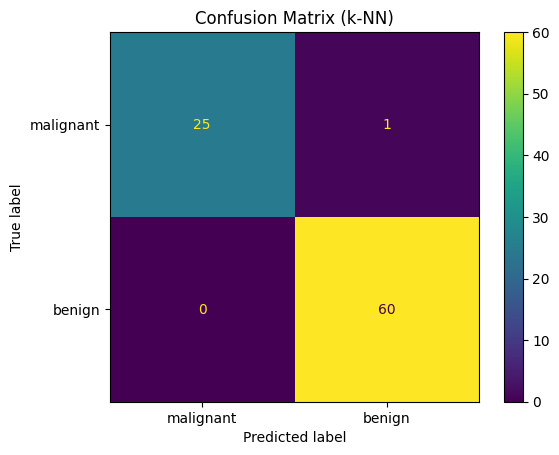

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=data.target_names)

disp.plot()

plt.title("Confusion Matrix (k-NN)")

plt.show()

### Confusion Matrix Interpretation



- **True Malignant predicted as Malignant (25):** These are correctly classified cancerous tumors (True Positives).
- **True Malignant predicted as Benign (1):** This is a misclassification where a cancerous tumor was predicted as benign (False Negative).
- **True Benign predicted as Malignant (0):** This would represent a benign tumor incorrectly predicted as malignant (False Positive), but in this case there are none.
- **True Benign predicted as Benign (60):** These are correctly classified non-cancerous tumors (True Negatives).



## 1.3 Decision Tree Classifier
---

In this section we train a Decision Tree classifier   
Decision Trees are supervised learning models that classify data by recursively splitting the dataset based on feature values. It is a greedy algorithm choosing best split at the time.

### 1.3.1 Model Initialization and Hyperparameter Tuning
---

Decision Trees have several hyperparameters that control the complexity of the model.  
In this experiment we tune two parameters:

- **max_depth**: the maximum depth of the tree
- **min_samples_split**: the minimum number of samples required to split a node

Testing different combinations of these parameters helps us prevent overfitting and find a model that generalizes well to unseen data. (Generalization Again)

In [ ]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

In [ ]:
max_depth_values = [2, 4, 6, 8, None]
min_samples_split_values = [2, 5, 10]

results = []

for depth in max_depth_values:

    for min_split in min_samples_split_values:

        dt = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split,
            random_state=42
        )

        dt.fit(X_train_std, y_train)

        y_val_pred = dt.predict(X_val_std)

        acc = accuracy_score(y_val, y_val_pred)

        results.append((depth, min_split, acc))

        print("max_depth =", depth,
              "min_samples_split =", min_split,
              "Validation Accuracy =", acc)

max_depth = 2 min_samples_split = 2 Validation Accuracy = 0.9176470588235294
max_depth = 2 min_samples_split = 5 Validation Accuracy = 0.9176470588235294
max_depth = 2 min_samples_split = 10 Validation Accuracy = 0.9176470588235294
max_depth = 4 min_samples_split = 2 Validation Accuracy = 0.9647058823529412
max_depth = 4 min_samples_split = 5 Validation Accuracy = 0.9411764705882353
max_depth = 4 min_samples_split = 10 Validation Accuracy = 0.9411764705882353
max_depth = 6 min_samples_split = 2 Validation Accuracy = 0.9647058823529412
max_depth = 6 min_samples_split = 5 Validation Accuracy = 0.9529411764705882
max_depth = 6 min_samples_split = 10 Validation Accuracy = 0.9529411764705882
max_depth = 8 min_samples_split = 2 Validation Accuracy = 0.9411764705882353
max_depth = 8 min_samples_split = 5 Validation Accuracy = 0.9411764705882353
max_depth = 8 min_samples_split = 10 Validation Accuracy = 0.9294117647058824
max_depth = None min_samples_split = 2 Validation Accuracy = 0.941176470

In [ ]:
# Finding Best max_depth and min_samples_split

best_config = max(results, key=lambda x: x[2])

best_depth = best_config[0]
best_min_split = best_config[1]

print("Best max_depth:", best_depth)
print("Best min_samples_split:", best_min_split)

Best max_depth: 4
Best min_samples_split: 2


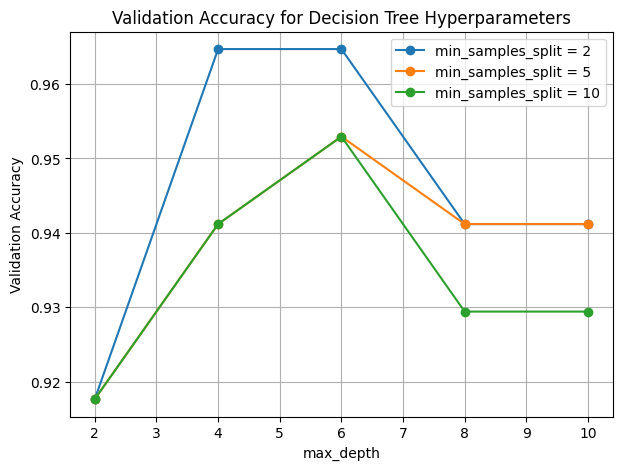

In [ ]:
depth_labels = [2,4,6,8,10]   # using 10 to represent None for plotting since after that it will stay flat

acc_split2 = []
acc_split5 = []
acc_split10 = []

for depth, min_split, acc in results:

    if depth is None:
        depth = 10

    if min_split == 2:
        acc_split2.append(acc)

    elif min_split == 5:
        acc_split5.append(acc)

    elif min_split == 10:
        acc_split10.append(acc)

plt.figure(figsize=(7,5))

plt.plot(depth_labels, acc_split2, marker='o', label="min_samples_split = 2")
plt.plot(depth_labels, acc_split5, marker='o', label="min_samples_split = 5")
plt.plot(depth_labels, acc_split10, marker='o', label="min_samples_split = 10")

plt.xlabel("max_depth")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Decision Tree Hyperparameters")

plt.legend()
plt.grid(True)

plt.show()

The plot shows how validation accuracy changes for different Decision Tree hyperparameter configurations.  
The best performance occurs when max_depth = 4 and min_samples_split = 2, which achieves the highest validation accuracy. Increasing the depth beyond this point does not improve performance and may lead to overfitting.

Note that if another pair had the same accuracy we always choose the simpler one to avoid overfitting

### 1.3.2 Final Model and Evaluation
---

After determining the best hyperparameter combination using the validation set, we retrain the Decision Tree using both the training and validation data combined.  
The final model is then evaluated on the test set to estimate its performance on unseen data.

In [ ]:
X_train_val = np.vstack((X_train_std, X_val_std))
y_train_val = np.concatenate((y_train, y_val))

In [ ]:
final_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_min_split,
    random_state=42
)

final_dt.fit(X_train_val, y_train_val)

y_test_pred_dt = final_dt.predict(X_test_std)

In [ ]:
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)

print("Decision Tree Test Accuracy:", dt_test_accuracy)

Decision Tree Test Accuracy: 0.9534883720930233


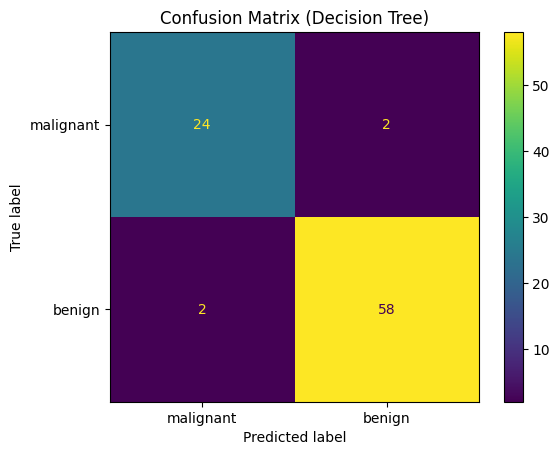

In [ ]:
cm_dt = confusion_matrix(y_test, y_test_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=data.target_names
)

disp.plot()

plt.title("Confusion Matrix (Decision Tree)")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix summarizes the classification performance of the Decision Tree model on the test dataset.

- **True Malignant predicted as Malignant (24):** These are cancerous tumors correctly classified by the model (True Positives).
- **True Malignant predicted as Benign (2):** These are malignant tumors incorrectly classified as benign (False Negatives).
- **True Benign predicted as Malignant (2):** These are benign tumors incorrectly classified as malignant (False Positives).
- **True Benign predicted as Benign (58):** These are benign tumors correctly classified by the model (True Negatives).

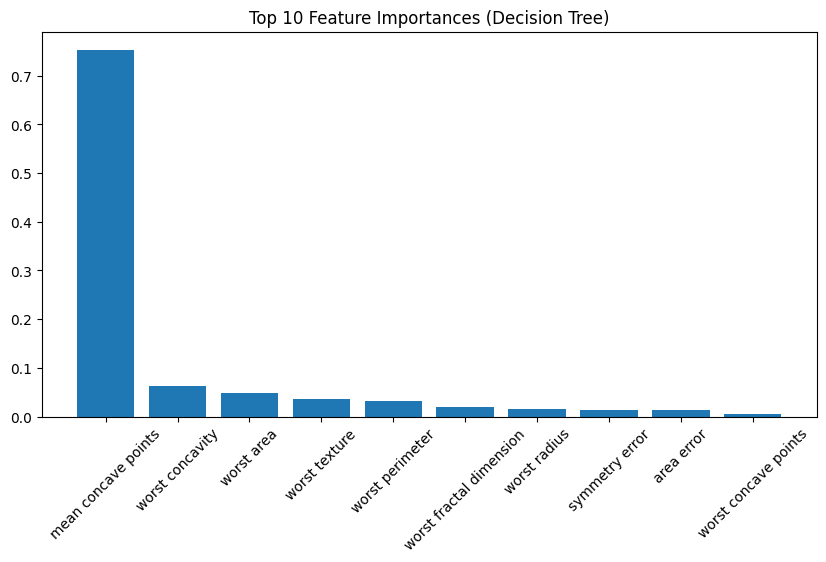

In [ ]:
importances = final_dt.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))

plt.bar(range(10), importances[indices][:10])

plt.xticks(range(10),
           data.feature_names[indices][:10],
           rotation=45)

plt.title("Top 10 Feature Importances (Decision Tree)")

plt.show()

### Feature Importance Interpretation

The bar chart shows the importance of the features used by the Decision Tree model. Feature importance measures how much each feature contributes to improving the classification decisions made by the tree.

The most informative feature in the model is **mean concave points**, which has the highest importance value. Other important features include **worst concavity**, **worst area**, **worst texture**, and **worst perimeter**.

These features describe characteristics, which are known to be strong indicators of malignancy. The higher importance values indicate that the Decision Tree relies heavily on these measurements when determining whether a tumor is malignant or benign.